<a href="https://colab.research.google.com/github/pradeep6kumar/value_iteration/blob/aoc/value_iteration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Value Iteration for 4x4 GridWorld

This notebook implements the Value Iteration algorithm for a 4x4 GridWorld problem where an agent starts at the top-left corner (state 0) and tries to reach the bottom-right corner (state 15). The agent can move up, down, left, or right with equal probability. The rewards are -1 for each move, and the terminal state (bottom-right) has a reward of 0.

## NumPy Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def value_iteration_gridworld():
    # Initialize parameters
    grid_size = 4  # 4x4 grid
    num_states = grid_size * grid_size  # 16 states
    num_actions = 4  # up, down, left, right
    gamma = 1.0  # discount factor
    theta = 1e-4  # convergence threshold

    # Initialize value function
    V = np.zeros((grid_size, grid_size))

    # Define rewards: -1 for all states except terminal state (bottom-right)
    rewards = np.full((grid_size, grid_size), -1)
    rewards[grid_size-1, grid_size-1] = 0  # terminal state has 0 reward

    # Define actions: up, down, left, right
    actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    # Value iteration
    iteration = 0
    while True:
        iteration += 1
        delta = 0  # track maximum change
        V_new = V.copy()

        # Update each state
        for i in range(grid_size):
            for j in range(grid_size):
                # Skip terminal state
                if i == grid_size-1 and j == grid_size-1:
                    continue

                # Calculate value for each action
                action_values = []
                for action in actions:
                    # Calculate next state
                    next_i = max(0, min(grid_size-1, i + action[0]))
                    next_j = max(0, min(grid_size-1, j + action[1]))

                    # Calculate value
                    action_value = rewards[i, j] + gamma * V[next_i, next_j]
                    action_values.append(action_value)

                # Update value function with average (equal probability for all actions)
                V_new[i, j] = sum(action_values) / num_actions

                # Track maximum change
                delta = max(delta, abs(V_new[i, j] - V[i, j]))

        # Update value function
        V = V_new

        # Check for convergence
        if delta < theta:
            break

    print(f"Value iteration converged after {iteration} iterations")
    print("Final value function:")
    print(V)

    return V, iteration

def plot_value_function(V, title="Value Function for 4x4 GridWorld"):
    """Plot the value function as a heatmap"""
    plt.figure(figsize=(8, 6))
    plt.imshow(V, cmap='viridis')
    plt.colorbar(label='Value')
    plt.title(title)

    # Add text annotations
    for i in range(V.shape[0]):
        for j in range(V.shape[1]):
            plt.text(j, i, f'{V[i, j]:.2f}',
                     ha='center', va='center',
                     color='white' if V[i, j] < -30 else 'black')

    plt.tight_layout()
    plt.show()

Value iteration converged after 471 iterations
Final value function:
[[-59.42367735 -57.42387125 -54.2813141  -51.71012579]
 [-57.42387125 -54.56699476 -49.71029394 -45.13926711]
 [-54.2813141  -49.71029394 -40.85391609 -29.99766609]
 [-51.71012579 -45.13926711 -29.99766609   0.        ]]


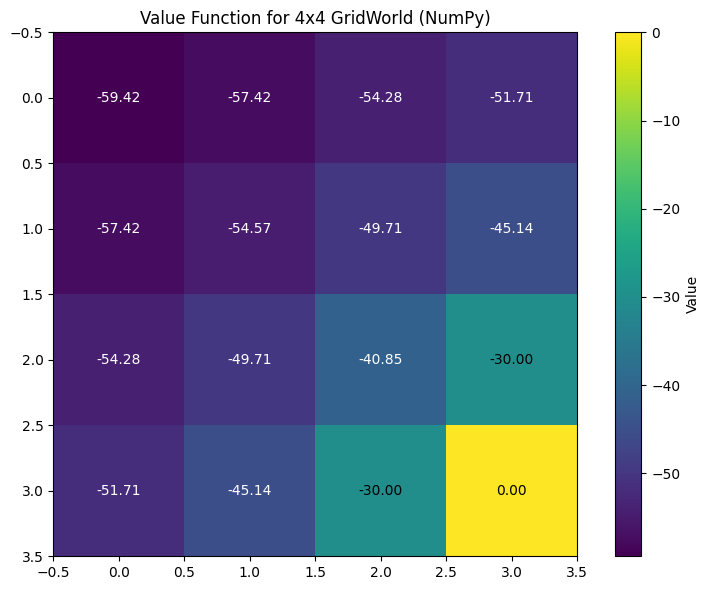

In [2]:
# Run the NumPy implementation
V_numpy, iterations_numpy = value_iteration_gridworld()
plot_value_function(V_numpy, "Value Function for 4x4 GridWorld (NumPy)")

## PyTorch Implementation

In [3]:
import torch

def value_iteration_gridworld_pytorch():
    # Initialize parameters
    grid_size = 4  # 4x4 grid
    num_states = grid_size * grid_size  # 16 states
    num_actions = 4  # up, down, left, right
    gamma = 1.0  # discount factor
    theta = 1e-4  # convergence threshold

    # Initialize value function
    V = torch.zeros((grid_size, grid_size))

    # Define rewards: -1 for all states except terminal state (bottom-right)
    rewards = torch.full((grid_size, grid_size), -1.0)
    rewards[grid_size-1, grid_size-1] = 0.0  # terminal state has 0 reward

    # Define actions: up, down, left, right
    actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    # Value iteration
    iteration = 0
    while True:
        iteration += 1
        delta = 0.0  # track maximum change
        V_new = V.clone()

        # Update each state
        for i in range(grid_size):
            for j in range(grid_size):
                # Skip terminal state
                if i == grid_size-1 and j == grid_size-1:
                    continue

                # Calculate value for each action
                action_values = torch.zeros(num_actions)
                for a, action in enumerate(actions):
                    # Calculate next state
                    next_i = max(0, min(grid_size-1, i + action[0]))
                    next_j = max(0, min(grid_size-1, j + action[1]))

                    # Calculate value
                    action_values[a] = rewards[i, j] + gamma * V[next_i, next_j]

                # Update value function with average (equal probability for all actions)
                V_new[i, j] = torch.mean(action_values)

                # Track maximum change
                delta = max(delta, abs(V_new[i, j].item() - V[i, j].item()))

        # Update value function
        V = V_new

        # Check for convergence
        if delta < theta:
            break

    print(f"Value iteration converged after {iteration} iterations")
    print("Final value function:")
    print(V)

    return V, iteration

def plot_value_function_pytorch(V, title="Value Function for 4x4 GridWorld (PyTorch)"):
    """Plot the value function as a heatmap"""
    V_np = V.numpy()
    plt.figure(figsize=(8, 6))
    plt.imshow(V_np, cmap='viridis')
    plt.colorbar(label='Value')
    plt.title(title)

    # Add text annotations
    for i in range(V.shape[0]):
        for j in range(V.shape[1]):
            plt.text(j, i, f'{V[i, j].item():.2f}',
                     ha='center', va='center',
                     color='white' if V[i, j].item() < -30 else 'black')

    plt.tight_layout()
    plt.show()

Value iteration converged after 471 iterations
Final value function:
tensor([[-59.4237, -57.4239, -54.2813, -51.7101],
        [-57.4239, -54.5670, -49.7103, -45.1393],
        [-54.2813, -49.7103, -40.8539, -29.9977],
        [-51.7101, -45.1393, -29.9977,   0.0000]])


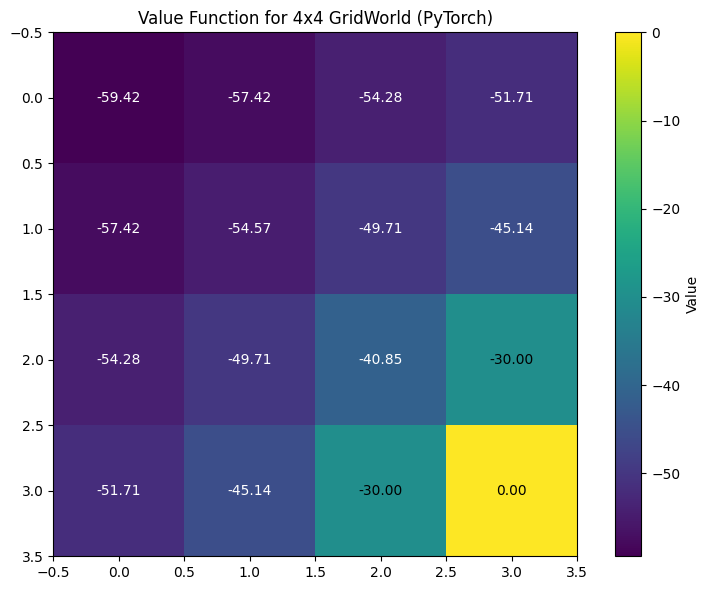

In [4]:
# Run the PyTorch implementation
V_pytorch, iterations_pytorch = value_iteration_gridworld_pytorch()
plot_value_function_pytorch(V_pytorch)

## Comparison of Results

Let's compare the results from both implementations:

In [6]:
print(f"NumPy implementation converged after {iterations_numpy} iterations")
print(f"PyTorch implementation converged after {iterations_pytorch} iterations")

# Convert PyTorch tensor to NumPy for comparison
V_pytorch_np = V_pytorch.numpy()

# Check if the results are similar
diff = np.abs(V_numpy - V_pytorch_np).max()
print(f"Maximum difference between implementations: {diff}")

# Display the final value function from NumPy implementation
print("\nFinal Value Function (NumPy):")
print(V_numpy)

NumPy implementation converged after 471 iterations
PyTorch implementation converged after 471 iterations
Maximum difference between implementations: 4.981292654804292e-06

Final Value Function (NumPy):
[[-59.42367735 -57.42387125 -54.2813141  -51.71012579]
 [-57.42387125 -54.56699476 -49.71029394 -45.13926711]
 [-54.2813141  -49.71029394 -40.85391609 -29.99766609]
 [-51.71012579 -45.13926711 -29.99766609   0.        ]]


## Understanding the Results

The value function shows the expected total reward when starting from each state and following the policy of random movement (equal probability for all four directions).

### Why are the values so negative?

The values are much more negative than just the minimum number of steps to the goal because:

1. **Random Movement**: The agent has an equal probability (0.25) of moving in any of the four directions, regardless of what's optimal.

2. **Wall Collisions**: When the agent tries to move off the grid, it stays in place but still incurs the -1 reward.

3. **Accumulated Penalties**: Due to random movement, the agent might revisit states multiple times or take inefficient paths.

For example, from many positions, only one direction leads toward the goal, while the other three directions either move away from the goal or hit walls. This means the agent often takes suboptimal paths, accumulating many more -1 rewards.

### Pattern in the Value Function

The pattern in the value function reflects the structure of the problem:
- The goal state (bottom-right) has value 0
- States closer to the goal have higher values (less negative)
- States farther from the goal have lower values (more negative)
- The starting state (top-left) has the lowest value because it's farthest from the goal

## Comparison with Dijkstra's Algorithm

Value Iteration and Dijkstra's Algorithm have similarities:

- Both find optimal paths through a graph or grid
- Both use iterative updates
- Both propagate information from one node/state to its neighbors

Key differences:

- **Dijkstra's Algorithm**: Finds the shortest path between two specific nodes in a deterministic graph
- **Value Iteration**: Finds the optimal policy for all states in a potentially stochastic environment

If we removed the randomness in our GridWorld problem (so the agent always moves in the chosen direction), Dijkstra's algorithm would be perfect for finding the shortest path from start to goal. Value Iteration is more general and can handle the additional complexities of reinforcement learning problems with stochastic transitions.